# Member Cluster - Model Pipeline

The model that was trained in the previous notebook is used here to apply the model to new data.

## Prepare the notebook

In [1]:
# Imports

import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import os

## Enter inputs

In [2]:
file_paths_list = [
    'Chapter_Leaders.csv',
    'District_Leaders.csv',
    'Chapters_and_Choruses.csv',
    'Quartets_in_District.csv',
    'District_Members.csv',
    'District_Members_in_Chapters.csv',
    'District_Members_in_Choruses.csv',
    'District_Members_in_Quartets.csv'
]

model_path = 'cluster_kmeans_model.pkl'
scaler_path = 'cluster_scaler.pkl'
reference_date = '2026-04-27'

## Create component functions

In [3]:
# Function to combine the raw data using SQL

def aggregate_data(file_paths_list):
    # Create a temporary database
    conn = sqlite3.connect(':memory:')

    for file in file_paths_list:

        # Get the file name without the file extension
        file_name = os.path.splitext(file)[0]

        # Read the CSV into a temporary DataFrame
        df = pd.read_csv(file)

        # Standardize column headers with lowercase and underscores instead of spaces
        df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

        # Clean up specific columns
        for col in df.columns:
        
            # Convert all of the date columns from strings to dates
            if 'date' in col:
                df[col] = pd.to_datetime(df[col], errors='coerce')

            # Drop the rows where the chorus_end_date is null, since these are known to be data entry errors
            if 'chorus_end_date' in col:
                df = df.dropna(subset=[col])

        # Write to SQL
        table_name = f"{file_name}_table"
        df.to_sql(table_name, conn, index=False, if_exists='replace')

    # SQL query to combine the CSVs and output the consolidated member table to run through the model
    query = '''
    WITH lapse_calculation AS (
        SELECT
            member_number,
            (julianday(LEAD(district_join_date) OVER (PARTITION BY member_number ORDER BY district_join_date)) - julianday(district_end_date)) AS gap_days
        FROM district_members_table
    ),
    lapse_stats AS (
        SELECT
            member_number,
            COUNT(CASE WHEN gap_days >=365 THEN 1 END) as significant_lapses
        FROM lapse_calculation
        GROUP BY member_number
    )

    SELECT 
        member.member_number,
        member.society_status,
        member.years_of_service,
        member.district_status,
        member.district_referral_count,
        member.gender,
        member.birthdate,
        member.district_original_join_date,
        member.district_most_recent_join_date,
        member.district_latest_end_date,
        member.district_tenure_days,

        COALESCE(chapter_table.current_chapter_count, 0) AS current_chapter_count,
        COALESCE(chapter_table.former_chapter_count, 0) AS former_chapter_count,

        COALESCE(chorus_table.current_chorus_count, 0) AS current_chorus_count,
        COALESCE(chorus_table.former_chorus_count, 0) AS former_chorus_count,

        COALESCE(quartet_table.current_quartet_count, 0) AS current_quartet_count,
        COALESCE(quartet_table.former_quartet_count, 0) AS former_quartet_count,

        COALESCE(chapter_leader_table.current_chapter_leader_count, 0) AS current_chapter_leader_count,
        COALESCE(chapter_leader_table.former_chapter_leader_count, 0) AS former_chapter_leader_count,

        COALESCE(district_leader_table.current_district_leader_count, 0) AS current_district_leader_count,
        COALESCE(district_leader_table.former_district_leader_count, 0) AS former_district_leader_count,

        COALESCE(lapse_stats.significant_lapses, 0) AS true_lapses

    FROM (
        SELECT
            member_number,
            society_status,
            years_of_service,
            district_status,
            pon_count AS district_referral_count,
            gender,
            birthdate,
            MIN(district_join_date) AS district_original_join_date,
            MAX(district_join_date) AS district_most_recent_join_date,
            MAX(district_end_date) AS district_latest_end_date,
            SUM(CASE
                WHEN district_end_date IS NOT NULL AND district_end_date != ''
                THEN julianday(district_end_date) - julianday(district_join_date)
                ELSE julianday('now') - julianday(district_join_date)
            END) AS district_tenure_days

        FROM district_members_table
        GROUP BY member_number
    ) AS member

    LEFT JOIN (
        SELECT 
            member_number,
            COUNT(CASE WHEN chapter_final_status = 1 THEN 1 END) AS current_chapter_count,
            COUNT(CASE WHEN chapter_final_status = 0 THEN 1 END) AS former_chapter_count
        FROM (
            SELECT
                member_number,
                chapter,
                MAX(CASE WHEN chapter_status = 'Current' THEN 1 ELSE 0 END) AS chapter_final_status
            FROM district_members_in_chapters_table
            GROUP BY member_number, chapter
        )
        GROUP BY member_number
    ) AS chapter_table ON member.member_number = chapter_table.member_number

    LEFT JOIN (
        SELECT 
            member_number,
            COUNT(CASE WHEN chorus_final_status = 1 THEN 1 END) AS current_chorus_count,
            COUNT(CASE WHEN chorus_final_status = 0 THEN 1 END) AS former_chorus_count
        FROM (
            SELECT
                member_number,
                chorus,
                MAX(CASE WHEN chorus_status = 'Current' THEN 1 ELSE 0 END) as chorus_final_status
            FROM district_members_in_choruses_table
            GROUP BY member_number, chorus
        )
        GROUP BY member_number
    ) AS chorus_table ON member.member_number = chorus_table.member_number

    LEFT JOIN (
        SELECT 
            member_number,
            COUNT(CASE WHEN quartet_final_status = 1 THEN 1 END) AS current_quartet_count,
            COUNT(CASE WHEN quartet_final_status = 0 THEN 1 END) AS former_quartet_count
        FROM (
            SELECT
                member_number,
                quartet_name,
                MAX(CASE WHEN status = 'Current' THEN 1 ELSE 0 END) as quartet_final_status
            FROM district_members_in_quartets_table
            GROUP BY member_number, quartet_name
        )
        GROUP BY member_number
    ) AS quartet_table ON member.member_number = quartet_table.member_number

    LEFT JOIN (
        SELECT
            member_number,
            COUNT(CASE WHEN chapter_leader_final_status = 1 THEN 1 END) AS current_chapter_leader_count,
            COUNT(CASE WHEN chapter_leader_final_status = 0 THEN 1 END) AS former_chapter_leader_count
        FROM (
            SELECT
                member_number,
                role,
                MAX(CASE WHEN status = 'Current' THEN 1 ELSE 0 END) as chapter_leader_final_status
            FROM chapter_leaders_table
            GROUP BY member_number, role
        )
        GROUP BY member_number
    ) AS chapter_leader_table ON member.member_number = chapter_leader_table.member_number

    LEFT JOIN (
        SELECT
            member_number,
            COUNT(CASE WHEN district_leader_final_status = 1 THEN 1 END) AS current_district_leader_count,
            COUNT(CASE WHEN district_leader_final_status = 0 THEN 1 END) AS former_district_leader_count
        FROM (
            SELECT
                member_number,
                officer_role,
                MAX(CASE WHEN status = 'Current' THEN 1 ELSE 0 END) as district_leader_final_status
            FROM district_leaders_table
            GROUP BY member_number, officer_role
        )
        GROUP BY member_number
    ) AS district_leader_table ON member.member_number = district_leader_table.member_number

    LEFT JOIN 
        lapse_stats ON member.member_number = lapse_stats.member_number


    ;'''

    # Run the SQL query and pull the output data to a DataFrame
    aggregated_member_data = pd.read_sql_query(query, conn)

    # Close the database connection
    conn.close()

    return aggregated_member_data

In [20]:
# Function to anonymize the member numbers according to the private mapping

def anonymize_member_number(aggregated_member_data, id_column='member_number', key_filepath='private_member_number_mapping.csv'):

    # Load the existing private member number mapping file
    key_df = pd.read_csv(key_filepath)

    # Create the lookup dictionary
    id_map = dict(zip(key_df['real_member_number'], key_df['fake_member_number']))

    # Identify if there are new members since the original member number mapping was done
    incoming_ids = aggregated_member_data[id_column].unique()
    new_ids = [id for id in incoming_ids if id not in id_map]

    # If there are new members, create a new anonymized member number for them
    if new_ids:
        # Find the largest current ID number to continue from there
        highest_id = key_df['fake_member_number'].str.replace('Num_', '').astype(int).max()

        new_mappings = []
        for i, real_id in enumerate(new_ids):
            next_fake_id = f'Num_{highest_id + 1 + i}'
            id_map[real_id] = next_fake_id
            new_mappings.append({'real_member_number': real_id, 'fake_member_number': next_fake_id})

        # Append the new members to the private member number mapping file
        updated_key_df = pd.concat([key_df, pd.DataFrame(new_mappings)], ignore_index=True)
        updated_key_df.to_csv(key_filepath, index=False)

    # Map the fake IDs to the aggregated data
    aggregated_member_data['member_number'] = aggregated_member_data['member_number'].map(id_map)

    return aggregated_member_data

In [5]:
# Function to preprocess the combined data

def preprocess_member_data(aggregated_member_data, reference_date):

    # Take the output of the SQL query and create a copy to make additional adjustments to
    member_data = aggregated_member_data.copy()

    # Convert reference date to datetime
    ref_date = pd.to_datetime(reference_date)

    # Convert the object columns to datetime
    member_data['birthdate'] = pd.to_datetime(member_data['birthdate'])
    member_data['district_original_join_date'] = pd.to_datetime(member_data['district_original_join_date'])
    member_data['district_latest_end_date'] = pd.to_datetime(member_data['district_latest_end_date'])

    # Calculate age, tenure, ever_district_leader_count, ever_chapter_leader_count
    member_data['age'] = round((ref_date - member_data['birthdate']).dt.days / 365.25)
    member_data['original_join_tenure'] = round((member_data['district_latest_end_date'] - member_data['district_original_join_date']).dt.days / 365.25)
    member_data['ever_district_leader_count'] = member_data['current_district_leader_count'] + member_data['former_district_leader_count']
    member_data['ever_chapter_leader_count'] = member_data['current_chapter_leader_count'] + member_data['former_chapter_leader_count']

    # Drop the rows with NaN
    member_data = member_data.dropna()

    # Filter to only members who are currently active in the society
    member_data_active = member_data[member_data['society_status']=='Active'].copy()

    # Select feature columns
    member_features = [
        'district_referral_count',
        'age',
        'original_join_tenure',
        'true_lapses',
        'current_chorus_count',
        'former_chorus_count',
        'current_quartet_count',
        'former_quartet_count',
        'ever_chapter_leader_count',
        'ever_district_leader_count'
    ]

    # Create the input
    X = member_data_active[member_features].copy()

    # Return the DataFrame and the input
    return member_data_active, X

In [6]:
# Function to apply the model

def apply_clustering_model(X_features, scaler_path, model_path):

    # Load the model
    scaler = joblib.load(scaler_path)
    kmeans = joblib.load(model_path)

    # Scale the data
    X_scaled = scaler.transform(X_features)

    # Predict the clusters
    predicted_clusters = kmeans.predict(X_scaled)

    return predicted_clusters

In [7]:
# Function to return basic visualizations of the clusters

def generate_visualizations(data):
    plt.figure(figsize=(6,4))
    ax = sns.barplot(
        x=data['cluster_label'].value_counts().index,
        y=data['cluster_label'].value_counts(),
        order=['A', 'B', 'C', 'D', 'E'])
    for container in ax.containers:
        ax.bar_label(container, label_type='center', color='white')
    plt.title('Member Count per Cluster')
    plt.show()

In [8]:
# Function to prepare the summary text output

def generate_text_report(data):

    # Define persona names
    personas = {
        'A': 'New & Uninvolved',
        'B': 'Sporadic Members',
        'C': 'Backbone',
        'D': 'Rising Stars',
        'E': 'Super Users'
    }

    print('MEMBER CLUSTER DEFITIONS')
    print('='*20)

    print('Cluster A: "New & Uninvolved" - New Members with Low Participation\n - Description: These members are younger and are new to being involved in barbershop. Their current participation is low in both choruses and quartets. Past participation is also low in both choruses and quartets.\n - Actions: These members are a retention risk because they are barely involved. They should be encouraged to join a chorus and/or quartet in order to get more value out of the hobby.\n')

    print('Cluster B: "Sporadic Members" - Members with Multiple Lapses and Former Involvement \n - Description: These members are older and have not been involved for a relatively long time, but stand out because of their high number of membership lapses as compared to other groups. They have been involved in the past in a chorus and multiple quartets, but are not currently very involved in either.\n - Actions: These members have gone in and out of their involvement. This could be due to life reasons, or just because they were not invested in the hobby. This group is also a retention risk, because they might be letting their membership lapse because they are not getting enough value from the hobby.\n')

    print('Cluster C: "Backbone" - Long-Time Members with Low Involvement\n - Description: These members are older and have been involved for a long time. They are currently and formerly active in a chorus but are not currently active in quartets. There is some amount of involvement in chapter leadership but not in district leadership.\n - Actions: These members are steady members of a single chorus. They should be looked at for chapter leadership as a way to get more involved in the hobby, especially since they are likely retired and have spare time.\n')

    print('Cluster D: "Rising Stars" - Younger Members with High Involvement in Choruses, Quartets, and Chapter Leadership\n - Description: These members are younger and are relatively new to the hobby. They are involved in a chorus, quartets, and are starting to get involved in chapter leadership.\n - Actions: This group is primed to be tapped for district leadership and other chapter leadership roles. They are dedicated to the hobby and already have experience in both choruses and quartets, and have some experience already in chapter leadership. They joined the hobby young and should be given opportunities to get involved in different ways, so they evolve into the "super users" of Cluster 2.\n')

    print('Cluster E: "Super Users" - Long-Time Members with Heavy Involvement in Leadership and Choruses \n - Description: These members are highly involved and are the ones who keep everything running. They are older and have been involved for a long time. They sing with multiple choruses but not many quartets. They are currently or formerly involved in district leadership and chapter leadership. Additionally, they recommend many other people to join the hobby.\n - Actions: These members are highly dedicated in their own involvement, and they bring new members into the hobby. Those who have not been involved in chapter leadership or district leadership should be tapped for these roles, since they have a wealth of experience to contribute. They should also be encouraged to continue to recommend new members so the hobby can continue growing.\n')

    # Calculate counts
    total_members = len(data)
    cluster_count = data['cluster_label'].value_counts().sort_index()

    # Print header
    print('\nMEMBER CLUSTERING ANALYSIS')
    print('='*20)

    # Print total member count
    print(f'Total members processed: {total_members}\n')

    # Print persona name, member count, and percentage of total for each cluster
    for cluster_id, count in cluster_count.items():
        percentage = (count / total_members) * 100
        persona_name = personas.get(cluster_id)

        print(f'Cluster {cluster_id}: {persona_name} - {count} members ({percentage:.1f}%)')

In [9]:
# Function to return prioritized lists of members

def generate_recommendations(data):

    # Print header
    print('RECOMMENDATIONS')
    print('='*20)

    # Generate recommendations for district leadership
    print('District Leadership Recommendations:')
    print('The following members are part of Cluster E, which means they are heavily involved. Many have already held chapter leadership roles but not district leadership roles, and they are young enough to continue in leadership roles for many years. Reach out to these members and encourage them to get involved in district leadership.')

    # Filter by:
        # Cluster = E
        # Never a district leader
        # 65 years old or younger
        # Currently or formerly a chapter leader
    # Sort by:
        # Current chapter leader roles (descending)
        # Former chapter leader roles (descending)
    # Return the top ten 
    district_leadership_list = data[(data['cluster_label']=='E') & (data['ever_district_leader_count']==0) & (data['age']<=65) & (data['ever_chapter_leader_count']>0)].sort_values(by=['current_chapter_leader_count','former_chapter_leader_count'], ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure', 'current_chapter_leader_count', 'former_chapter_leader_count', 'district_referral_count']][:10]
    district_leadership_list['age'] = district_leadership_list['age'].round().astype(int)
    district_leadership_list['original_join_tenure'] = district_leadership_list['original_join_tenure'].round().astype(int)
    display(district_leadership_list.style.hide(axis='index'))

    # Generate recommendations for chapter leadership
    print('Chapter Leadership Recommendations:')
    print('The following members are either part of Cluster E, which means they are heavily involved, but have not yet held chapter leadership roles; or part of Cluster D, which means they are younger members with high involvement. Reach out to these members and encourage them to get involved in chapter leadership.')
    
    # Filter by:
        # Cluster = E or D
        # Never a chapter leader
        # 65 years old or younger
    # Sort by:
        # Tenure (descending)
    chapter_leadership_list = data[((data['cluster_label']=='E') | (data['cluster_label']=='D')) & (data['ever_chapter_leader_count']==0) & (data['age']<=65)].sort_values(by='original_join_tenure', ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure']][:10]
    chapter_leadership_list['age'] = chapter_leadership_list['age'].round().astype(int)
    chapter_leadership_list['original_join_tenure'] = chapter_leadership_list['original_join_tenure'].round().astype(int)
    display(chapter_leadership_list.style.hide(axis='index'))

    # Generate retention risks
    print('Retention Risks (part 1):')
    print('The following members are part of Cluster A, which means they are not very involved. The have been members for a relatively longer time but have not recently been involved in any choruses or quartets. Encourage them to get involved in a chorus and/or quartet again, in order to continue getting value from their membership.')

    # Filter by:
        # Cluster = A
        # Currently in 0 choruses
        # Currently in 0 quartets
    # Sort by:
        # Tenure (descending)
    retention_list1 = data[(data['cluster_label']=='A') & (data['current_chorus_count']==0) & (data['current_quartet_count']==0)].sort_values(by='original_join_tenure', ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure', 'former_chorus_count', 'former_quartet_count']][:10]
    retention_list1['age'] = retention_list1['age'].round().astype(int)
    retention_list1['original_join_tenure'] = retention_list1['original_join_tenure'].round().astype(int)
    display(retention_list1.style.hide(axis='index'))

    print('Retention Risks (part 2):')
    print('The following members are part of Cluster A, and are relatively new to the hobby but have barely been involved. Encourage them to join a chorus and/or quartet in order to start getting more involved.')
    
    # Filter by:
        # Cluster = A
        # Never in any choruses
        # Not currently in a quartet
        # Tenure is less than 3 years (in the district and overall, to account for people who move and change districts)
    # Sort by:
        # Tenure (descending)
    retention_list2 = data[(data['cluster_label']=='A') & (data['current_chorus_count']==0) & (data['former_chorus_count']==0) & (data['current_quartet_count']==0) & (data['former_quartet_count']==0) & (data['original_join_tenure']<3) & (data['district_status']=='Current') & (data['years_of_service']<3)].sort_values(by='original_join_tenure', ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure']][:10]
    retention_list2['age'] = retention_list2['age'].round().astype(int)
    retention_list2['original_join_tenure'] = retention_list2['original_join_tenure'].round().astype(int)
    display(retention_list2.style.hide(axis='index'))


In [18]:
# Function to combine the component functions and run the full pipeline

def run_member_cluster_pipeline(file_paths_list, reference_date, scaler_path, model_path):

    # Run the SQL query to aggregate_data from the raw CSVs
    aggregated_data = aggregate_data(file_paths_list)

    # Anonymize the member number
    data = anonymize_member_number(aggregated_data)

    # Clean the data and prepare the features
    data, X_features = preprocess_member_data(aggregated_data, reference_date)

    # Run the model to get predicted clusters
    data['cluster'] = apply_clustering_model(X_features, scaler_path, model_path)

    # Map the cluster numbers to labels
    mapping = {
        0: 'A',
        1: 'B',
        2: 'E',
        3: 'C',
        4: 'D'
    }
    data['cluster_label'] = data['cluster'].map(mapping)

    # Print text report
    generate_text_report(data)

    # Generate visualizations
    generate_visualizations(data)

    # Print recommendations report
    generate_recommendations(data)

## Run the pipeline

MEMBER CLUSTER DEFITIONS
Cluster A: "New & Uninvolved" - New Members with Low Participation
 - Description: These members are younger and are new to being involved in barbershop. Their current participation is low in both choruses and quartets. Past participation is also low in both choruses and quartets.
 - Actions: These members are a retention risk because they are barely involved. They should be encouraged to join a chorus and/or quartet in order to get more value out of the hobby.

Cluster B: "Sporadic Members" - Members with Multiple Lapses and Former Involvement 
 - Description: These members are older and have not been involved for a relatively long time, but stand out because of their high number of membership lapses as compared to other groups. They have been involved in the past in a chorus and multiple quartets, but are not currently very involved in either.
 - Actions: These members have gone in and out of their involvement. This could be due to life reasons, or just becau

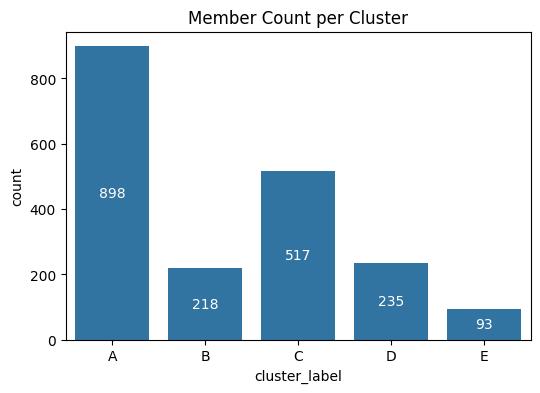

RECOMMENDATIONS
District Leadership Recommendations:
The following members are part of Cluster E, which means they are heavily involved. Many have already held chapter leadership roles but not district leadership roles, and they are young enough to continue in leadership roles for many years. Reach out to these members and encourage them to get involved in district leadership.


member_number,age,gender,original_join_tenure,current_chapter_leader_count,former_chapter_leader_count,district_referral_count
Num_5008,63,Male,37,4,2,6
Num_4104,50,Male,19,2,2,13
Num_2349,63,Male,42,1,6,4
Num_1311,45,Male,25,1,4,14
Num_1280,42,Male,31,1,3,0
Num_800,63,Male,49,1,2,0
Num_4670,57,Male,35,1,1,2
Num_5227,54,Male,47,1,0,2
Num_3464,48,Male,31,1,0,8
Num_570,45,Male,24,1,0,4


Chapter Leadership Recommendations:
The following members are either part of Cluster E, which means they are heavily involved, but have not yet held chapter leadership roles; or part of Cluster D, which means they are younger members with high involvement. Reach out to these members and encourage them to get involved in chapter leadership.


member_number,age,gender,original_join_tenure
Num_4789,60,Male,39
Num_5744,65,Male,33
Num_2999,57,Male,32
Num_4481,65,Male,30
Num_2902,60,Male,28
Num_6425,57,Male,27
Num_2077,37,Male,22
Num_6211,42,Male,21
Num_85,64,Male,18
Num_4878,40,Male,18


Retention Risks (part 1):
The following members are part of Cluster A, which means they are not very involved. The have been members for a relatively longer time but have not recently been involved in any choruses or quartets. Encourage them to get involved in a chorus and/or quartet again, in order to continue getting value from their membership.


member_number,age,gender,original_join_tenure,former_chorus_count,former_quartet_count
Num_4859,61,Male,39,0,3
Num_2582,50,Male,36,1,0
Num_2610,68,Male,34,0,1
Num_5047,65,Male,32,0,1
Num_3921,80,Male,31,0,1
Num_2658,74,Male,28,0,1
Num_4838,79,Male,25,1,0
Num_6865,73,Male,22,1,1
Num_3439,85,Male,21,1,0
Num_193,64,Male,21,1,0


Retention Risks (part 2):
The following members are part of Cluster A, and are relatively new to the hobby but have barely been involved. Encourage them to join a chorus and/or quartet in order to start getting more involved.


member_number,age,gender,original_join_tenure
Num_375,79,Male,2
Num_4488,24,Male,2
Num_3125,58,Female,2
Num_1699,41,Female,2
Num_4769,22,Male,1
Num_6475,70,Female,1
Num_6502,35,Male,1
Num_1777,75,Male,1
Num_5263,62,Male,1
Num_5024,38,Female,1


In [21]:
run_member_cluster_pipeline(
    file_paths_list=file_paths_list,
    reference_date=reference_date,
    scaler_path=scaler_path,
    model_path=model_path)